In [51]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris

# ==============================
# 1. GINI IMPURITY
# ==============================
def gini_impurity(y):
    if len(y) == 0:
        return 0
    _, counts = np.unique(y, return_counts=True)
    probs = counts / len(y)
    return 1-np.sum(probs**2)


# ==============================
# 2. VERBOSE SPLIT EVALUATION
# ==============================
def evaluate_split_verbose(X_column, y, threshold):
    lhs_mask = X_column < threshold
    rhs_mask = ~lhs_mask
    
    y_lhs = y[lhs_mask]
    y_rhs = y[rhs_mask]
    
    n_lhs, n_rhs = len(y_lhs), len(y_rhs)
    n_total = n_lhs + n_rhs
    
    if n_lhs == 0 or n_rhs == 0:
        return None
    
    def gini_details(y_subset):
        classes, counts = np.unique(y_subset, return_counts=True)
        probs = counts / len(y_subset)
        g = 1 - np.sum(probs**2)
        return dict(zip(classes, probs)), g
    
    probs_l, g_l = gini_details(y_lhs)
    probs_r, g_r = gini_details(y_rhs)
    
    g_split = (n_lhs/n_total)*g_l + (n_rhs/n_total)*g_r
    
    print(f"\nThreshold: {threshold:.3f}")
    print(f" LHS size={n_lhs}, probs={probs_l}, Gini={g_l:.4f}")
    print(f" RHS size={n_rhs}, probs={probs_r}, Gini={g_r:.4f}")
    print(f" --> Weighted Gini: {g_split:.4f}")
    
    return g_split


# ==============================
# 3. GINI GAIN
# ==============================
def gini_gain(parent, left, right):
    n = len(parent)
    return gini_impurity(parent) - (
        (len(left)/n)*gini_impurity(left) +
        (len(right)/n)*gini_impurity(right)
    )



In [52]:
# ==============================
# 4. BEST SPLIT (FULL SEARCH)
# ==============================
def best_split_verbose(X, y):
    best = {
        "feature": None,
        "threshold": None,
        "gini": float('inf'),
        "gain": 0
    }
    
    parent_gini = gini_impurity(y)
    print(f"\nParent Gini: {parent_gini:.4f}")
    
    for feature in range(X.shape[1]):
        values = np.sort(np.unique(X[:, feature]))
        splits = (values[:-1] + values[1:]) / 2
        
        print(f"\n--- Feature {feature} ---")
        
        for s in splits:
            lhs = y[X[:, feature] < s]
            rhs = y[X[:, feature] >= s]
            
            if len(lhs) == 0 or len(rhs) == 0:
                continue
            
            g = (len(lhs)/len(y))*gini_impurity(lhs) + \
                (len(rhs)/len(y))*gini_impurity(rhs)
            
            gain = parent_gini - g
            
            print(f"Threshold {s:.2f} → Gini {g:.4f}, Gain {gain:.4f}")
            
            if g < best["gini"]:
                best.update({
                    "feature": feature,
                    "threshold": s,
                    "gini": g,
                    "gain": gain
                })
    
    print("\n✅ BEST SPLIT FOUND:", best)
    return best




In [53]:
# ==============================
# 5. NODE CLASS
# ==============================
class Node:
    def __init__(self, feature=None, threshold=None, left=None, right=None, value=None, depth=0):
        self.feature = feature
        self.threshold = threshold
        self.left = left
        self.right = right
        self.value = value
        self.depth = depth




In [54]:
# ==============================
# 6. VISUALIZE SPLIT
# ==============================
def plot_split(X, y, feature, threshold, depth):
    plt.figure()
    
    for i in range(3):
        plt.scatter(X[y==i, 0], X[y==i, 1], label=f"class {i}")
    
    if feature == 0:
        plt.axvline(threshold, color='red')
    else:
        plt.axhline(threshold, color='red')
    
    plt.title(f"Depth {depth} Split (Feature {feature}, Threshold {threshold:.2f})")
    plt.legend()
    plt.show()


# ==============================
# 7. BUILD TREE (VERBOSE)
# ==============================
def build_tree_verbose(X, y, depth=0, max_depth=3, min_samples=2):
    
    print(f"\n{'='*50}")
    print(f"DEPTH {depth} | Samples={len(y)} | Gini={gini_impurity(y):.4f}")
    
    # STOPPING CONDITIONS
    if len(y) < min_samples or depth >= max_depth or gini_impurity(y) == 0:
        leaf = np.bincount(y).argmax()
        print(f"--> LEAF NODE: Class {leaf}")
        return Node(value=leaf, depth=depth)
    
    split = best_split_verbose(X, y)
    
    if split["feature"] is None:
        leaf = np.bincount(y).argmax()
        return Node(value=leaf, depth=depth)
    
    f, t = split["feature"], split["threshold"]
    
    print(f"\n🔥 APPLYING SPLIT: Feature {f} < {t:.2f}")
    print(f"Gini Decrease: {split['gain']:.4f}")
    
    plot_split(X, y, f, t, depth)
    
    left_mask = X[:, f] < t
    right_mask = ~left_mask
    
    left = build_tree_verbose(X[left_mask], y[left_mask], depth+1, max_depth, min_samples)
    right = build_tree_verbose(X[right_mask], y[right_mask], depth+1, max_depth, min_samples)
    
    return Node(f, t, left, right, depth=depth)




In [55]:
# ==============================
# 8. PREDICTION
# ==============================
def predict_one(x, node):
    if node.value is not None:
        return node.value
    
    if x[node.feature] < node.threshold:
        return predict_one(x, node.left)
    else:
        return predict_one(x, node.right)


def predict(X, tree):
    return np.array([predict_one(x, tree) for x in X])


# ==============================
# 9. DECISION BOUNDARY
# ==============================
def plot_decision_boundary(X, y, tree):
    x_min, x_max = X[:, 0].min()-1, X[:, 0].max()+1
    y_min, y_max = X[:, 1].min()-1, X[:, 1].max()+1
    
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                         np.linspace(y_min, y_max, 100))
    
    grid = np.c_[xx.ravel(), yy.ravel()]
    preds = predict(grid, tree)
    preds = preds.reshape(xx.shape)
    
    plt.contourf(xx, yy, preds, alpha=0.3)
    
    for i in range(3):
        plt.scatter(X[y==i, 0], X[y==i, 1], label=f"class {i}")
    
    plt.title("Final Decision Regions")
    plt.legend()
    plt.show()





DEPTH 0 | Samples=150 | Gini=0.6667

Parent Gini: 0.6667

--- Feature 0 ---
Threshold 1.05 → Gini 0.6622, Gain 0.0045
Threshold 1.15 → Gini 0.6577, Gain 0.0090
Threshold 1.25 → Gini 0.6484, Gain 0.0183
Threshold 1.35 → Gini 0.6139, Gain 0.0528
Threshold 1.45 → Gini 0.5397, Gain 0.1270
Threshold 1.55 → Gini 0.4484, Gain 0.2183
Threshold 1.65 → Gini 0.3899, Gain 0.2767
Threshold 1.80 → Gini 0.3529, Gain 0.3137
Threshold 2.45 → Gini 0.3333, Gain 0.3333
Threshold 3.15 → Gini 0.3430, Gain 0.3236
Threshold 3.40 → Gini 0.3608, Gain 0.3059
Threshold 3.55 → Gini 0.3764, Gain 0.2903
Threshold 3.65 → Gini 0.3835, Gain 0.2832
Threshold 3.75 → Gini 0.3901, Gain 0.2766
Threshold 3.85 → Gini 0.3963, Gain 0.2704
Threshold 3.95 → Gini 0.4124, Gain 0.2543
Threshold 4.05 → Gini 0.4315, Gain 0.2352
Threshold 4.15 → Gini 0.4387, Gain 0.2279
Threshold 4.25 → Gini 0.4438, Gain 0.2229
Threshold 4.35 → Gini 0.4444, Gain 0.2222
Threshold 4.45 → Gini 0.4419, Gain 0.2248
Threshold 4.55 → Gini 0.4342, Gain 0.2324

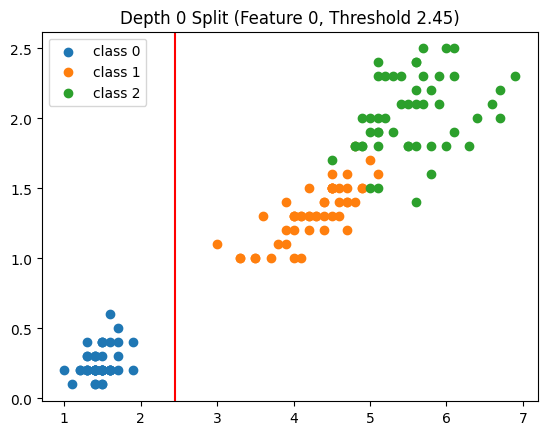


DEPTH 1 | Samples=50 | Gini=0.0000
--> LEAF NODE: Class 0

DEPTH 1 | Samples=100 | Gini=0.5000

Parent Gini: 0.5000

--- Feature 0 ---
Threshold 3.15 → Gini 0.4949, Gain 0.0051
Threshold 3.40 → Gini 0.4845, Gain 0.0155
Threshold 3.55 → Gini 0.4737, Gain 0.0263
Threshold 3.65 → Gini 0.4681, Gain 0.0319
Threshold 3.75 → Gini 0.4624, Gain 0.0376
Threshold 3.85 → Gini 0.4565, Gain 0.0435
Threshold 3.95 → Gini 0.4382, Gain 0.0618
Threshold 4.05 → Gini 0.4048, Gain 0.0952
Threshold 4.15 → Gini 0.3827, Gain 0.1173
Threshold 4.25 → Gini 0.3506, Gain 0.1494
Threshold 4.35 → Gini 0.3333, Gain 0.1667
Threshold 4.45 → Gini 0.2958, Gain 0.2042
Threshold 4.55 → Gini 0.2372, Gain 0.2628
Threshold 4.65 → Gini 0.1992, Gain 0.3008
Threshold 4.75 → Gini 0.1265, Gain 0.3735
Threshold 4.85 → Gini 0.1301, Gain 0.3699
Threshold 4.95 → Gini 0.1449, Gain 0.3551
Threshold 5.05 → Gini 0.1716, Gain 0.3284
Threshold 5.15 → Gini 0.2424, Gain 0.2576
Threshold 5.25 → Gini 0.2647, Gain 0.2353
Threshold 5.35 → Gini 0.

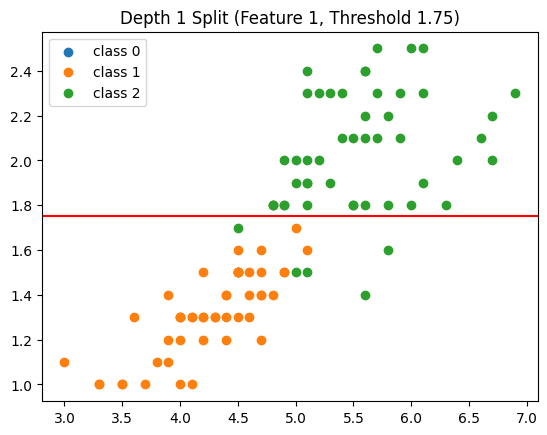


DEPTH 2 | Samples=54 | Gini=0.1680

Parent Gini: 0.1680

--- Feature 0 ---
Threshold 3.15 → Gini 0.1677, Gain 0.0003
Threshold 3.40 → Gini 0.1670, Gain 0.0010
Threshold 3.55 → Gini 0.1663, Gain 0.0017
Threshold 3.65 → Gini 0.1659, Gain 0.0021
Threshold 3.75 → Gini 0.1655, Gain 0.0026
Threshold 3.85 → Gini 0.1651, Gain 0.0030
Threshold 3.95 → Gini 0.1637, Gain 0.0044
Threshold 4.05 → Gini 0.1608, Gain 0.0072
Threshold 4.15 → Gini 0.1587, Gain 0.0093
Threshold 4.25 → Gini 0.1553, Gain 0.0127
Threshold 4.35 → Gini 0.1533, Gain 0.0148
Threshold 4.45 → Gini 0.1481, Gain 0.0199
Threshold 4.55 → Gini 0.1493, Gain 0.0187
Threshold 4.65 → Gini 0.1419, Gain 0.0261
Threshold 4.75 → Gini 0.1185, Gain 0.0495
Threshold 4.85 → Gini 0.1103, Gain 0.0577
Threshold 4.95 → Gini 0.0856, Gain 0.0824
Threshold 5.05 → Gini 0.0989, Gain 0.0691
Threshold 5.35 → Gini 0.1047, Gain 0.0633
Threshold 5.70 → Gini 0.1370, Gain 0.0311

--- Feature 1 ---
Threshold 1.05 → Gini 0.1655, Gain 0.0026
Threshold 1.15 → Gini 0

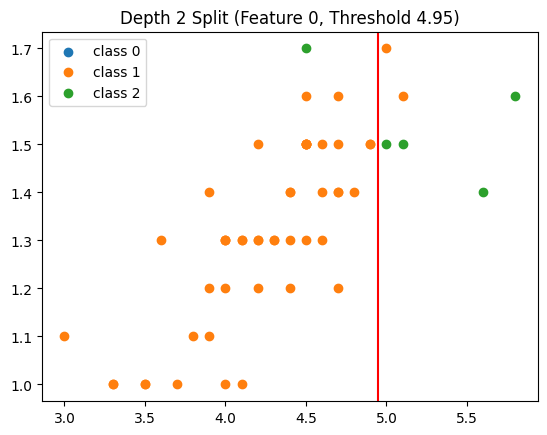


DEPTH 3 | Samples=48 | Gini=0.0408
--> LEAF NODE: Class 1

DEPTH 3 | Samples=6 | Gini=0.4444
--> LEAF NODE: Class 2

DEPTH 2 | Samples=46 | Gini=0.0425

Parent Gini: 0.0425

--- Feature 0 ---
Threshold 4.85 → Gini 0.0290, Gain 0.0135
Threshold 4.95 → Gini 0.0362, Gain 0.0063
Threshold 5.05 → Gini 0.0380, Gain 0.0045
Threshold 5.15 → Gini 0.0404, Gain 0.0022
Threshold 5.25 → Gini 0.0408, Gain 0.0018
Threshold 5.35 → Gini 0.0411, Gain 0.0015
Threshold 5.45 → Gini 0.0413, Gain 0.0012
Threshold 5.55 → Gini 0.0416, Gain 0.0009
Threshold 5.65 → Gini 0.0419, Gain 0.0006
Threshold 5.75 → Gini 0.0421, Gain 0.0005
Threshold 5.85 → Gini 0.0422, Gain 0.0004
Threshold 5.95 → Gini 0.0422, Gain 0.0003
Threshold 6.05 → Gini 0.0423, Gain 0.0002
Threshold 6.20 → Gini 0.0424, Gain 0.0001
Threshold 6.35 → Gini 0.0424, Gain 0.0001
Threshold 6.50 → Gini 0.0424, Gain 0.0001
Threshold 6.65 → Gini 0.0425, Gain 0.0001
Threshold 6.80 → Gini 0.0425, Gain 0.0000

--- Feature 1 ---
Threshold 1.85 → Gini 0.0399, Ga

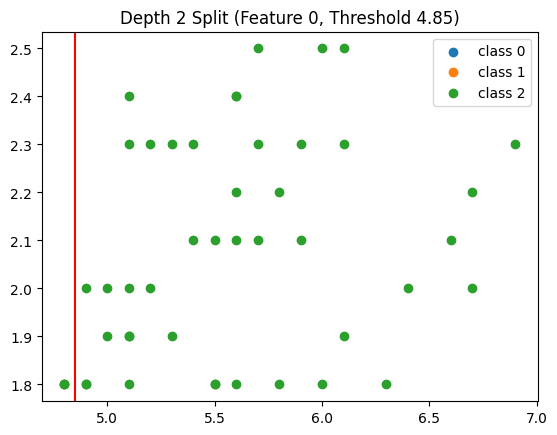


DEPTH 3 | Samples=3 | Gini=0.4444
--> LEAF NODE: Class 2

DEPTH 3 | Samples=43 | Gini=0.0000
--> LEAF NODE: Class 2


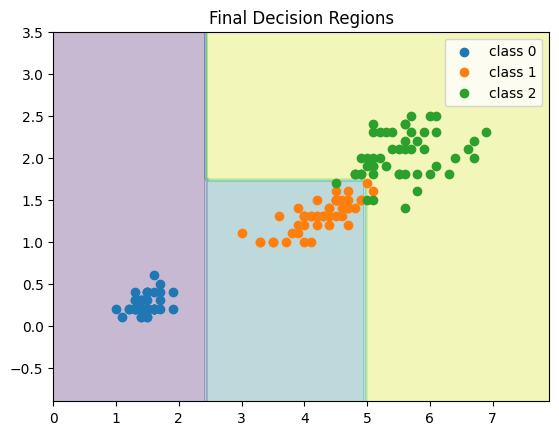

In [57]:
# ==============================
# 10. RUN EVERYTHING
# ==============================
iris = load_iris()
X = iris.data[:, 2:4]  # petal length & width
y = iris.target

tree = build_tree_verbose(X, y, max_depth=3)

plot_decision_boundary(X, y, tree)

In [33]:
from sklearn.model_selection import train_test_split

# Stratified 70/30 split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    stratify=y,
)

print("Train size:", len(y_train))
print("Test size:", len(y_test))

# Check class balance
print("Train class distribution:", np.bincount(y_train))
print("Test class distribution:", np.bincount(y_test))

Train size: 105
Test size: 45
Train class distribution: [35 35 35]
Test class distribution: [15 15 15]



DEPTH 0 | Samples=105 | Gini=0.6667

Parent Gini: 0.6667

--- Feature 0 ---
Threshold 1.05 → Gini 0.6603, Gain 0.0064
Threshold 1.15 → Gini 0.6537, Gain 0.0129
Threshold 1.25 → Gini 0.6403, Gain 0.0264
Threshold 1.35 → Gini 0.6042, Gain 0.0625
Threshold 1.45 → Gini 0.5194, Gain 0.1473
Threshold 1.55 → Gini 0.4242, Gain 0.2424
Threshold 1.65 → Gini 0.4000, Gain 0.2667
Threshold 1.80 → Gini 0.3611, Gain 0.3056
Threshold 2.45 → Gini 0.3333, Gain 0.3333
Threshold 3.15 → Gini 0.3470, Gain 0.3196
Threshold 3.40 → Gini 0.3710, Gain 0.2956
Threshold 3.55 → Gini 0.3910, Gain 0.2756
Threshold 3.65 → Gini 0.3996, Gain 0.2670
Threshold 3.75 → Gini 0.4074, Gain 0.2593
Threshold 3.85 → Gini 0.4144, Gain 0.2523
Threshold 3.95 → Gini 0.4259, Gain 0.2407
Threshold 4.05 → Gini 0.4405, Gain 0.2262
Threshold 4.15 → Gini 0.4424, Gain 0.2242
Threshold 4.25 → Gini 0.4444, Gain 0.2223
Threshold 4.35 → Gini 0.4444, Gain 0.2223
Threshold 4.45 → Gini 0.4379, Gain 0.2288
Threshold 4.55 → Gini 0.4144, Gain 0.2523

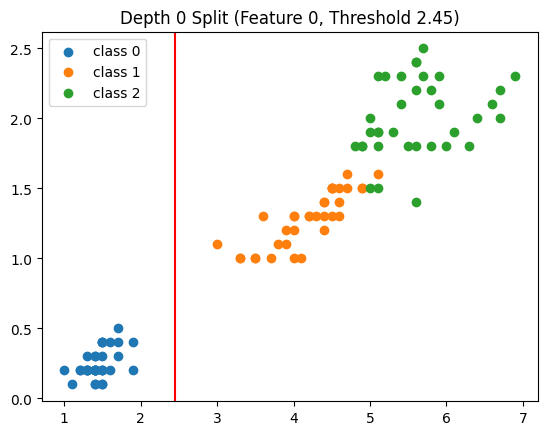


DEPTH 1 | Samples=35 | Gini=0.0000
--> LEAF NODE: Class 0

DEPTH 1 | Samples=70 | Gini=0.5000

Parent Gini: 0.5000

--- Feature 0 ---
Threshold 3.15 → Gini 0.4928, Gain 0.0072
Threshold 3.40 → Gini 0.4776, Gain 0.0224
Threshold 3.55 → Gini 0.4615, Gain 0.0385
Threshold 3.65 → Gini 0.4531, Gain 0.0469
Threshold 3.75 → Gini 0.4444, Gain 0.0556
Threshold 3.85 → Gini 0.4355, Gain 0.0645
Threshold 3.95 → Gini 0.4167, Gain 0.0833
Threshold 4.05 → Gini 0.3750, Gain 0.1250
Threshold 4.15 → Gini 0.3636, Gain 0.1364
Threshold 4.25 → Gini 0.3396, Gain 0.1604
Threshold 4.35 → Gini 0.3269, Gain 0.1731
Threshold 4.45 → Gini 0.2708, Gain 0.2292
Threshold 4.55 → Gini 0.1860, Gain 0.3140
Threshold 4.65 → Gini 0.1250, Gain 0.3750
Threshold 4.75 → Gini 0.0789, Gain 0.4211
Threshold 4.85 → Gini 0.1065, Gain 0.3935
Threshold 4.95 → Gini 0.1065, Gain 0.3935
Threshold 5.05 → Gini 0.1733, Gain 0.3267
Threshold 5.15 → Gini 0.2391, Gain 0.2609
Threshold 5.25 → Gini 0.2553, Gain 0.2447
Threshold 5.35 → Gini 0.2

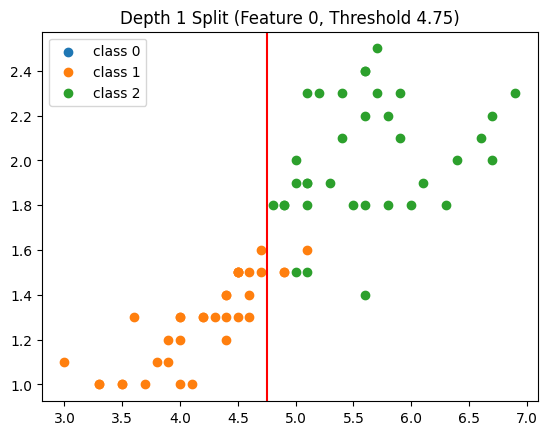


DEPTH 2 | Samples=32 | Gini=0.0000
--> LEAF NODE: Class 1

DEPTH 2 | Samples=38 | Gini=0.1454

Parent Gini: 0.1454

--- Feature 0 ---
Threshold 4.85 → Gini 0.1451, Gain 0.0003
Threshold 4.95 → Gini 0.1142, Gain 0.0312
Threshold 5.05 → Gini 0.1298, Gain 0.0156
Threshold 5.15 → Gini 0.1241, Gain 0.0214
Threshold 5.25 → Gini 0.1263, Gain 0.0191
Threshold 5.35 → Gini 0.1283, Gain 0.0171
Threshold 5.45 → Gini 0.1316, Gain 0.0139
Threshold 5.55 → Gini 0.1330, Gain 0.0125
Threshold 5.65 → Gini 0.1382, Gain 0.0073
Threshold 5.75 → Gini 0.1397, Gain 0.0058
Threshold 5.85 → Gini 0.1410, Gain 0.0045
Threshold 5.95 → Gini 0.1421, Gain 0.0033
Threshold 6.05 → Gini 0.1426, Gain 0.0028
Threshold 6.20 → Gini 0.1431, Gain 0.0023
Threshold 6.35 → Gini 0.1435, Gain 0.0019
Threshold 6.50 → Gini 0.1440, Gain 0.0015
Threshold 6.65 → Gini 0.1444, Gain 0.0011
Threshold 6.80 → Gini 0.1451, Gain 0.0003

--- Feature 1 ---
Threshold 1.45 → Gini 0.1451, Gain 0.0003
Threshold 1.55 → Gini 0.1142, Gain 0.0312
Thresh

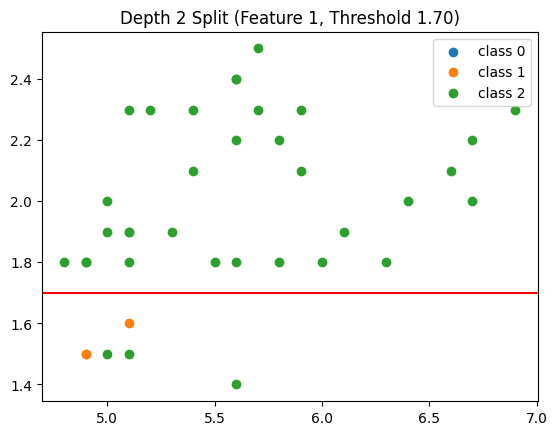


DEPTH 3 | Samples=6 | Gini=0.5000

Parent Gini: 0.5000

--- Feature 0 ---
Threshold 4.95 → Gini 0.2500, Gain 0.2500
Threshold 5.05 → Gini 0.4444, Gain 0.0556
Threshold 5.35 → Gini 0.4000, Gain 0.1000

--- Feature 1 ---
Threshold 1.45 → Gini 0.4000, Gain 0.1000
Threshold 1.55 → Gini 0.4000, Gain 0.1000

✅ BEST SPLIT FOUND: {'feature': 0, 'threshold': 4.95, 'gini': 0.25, 'gain': 0.25}

🔥 APPLYING SPLIT: Feature 0 < 4.95
Gini Decrease: 0.2500


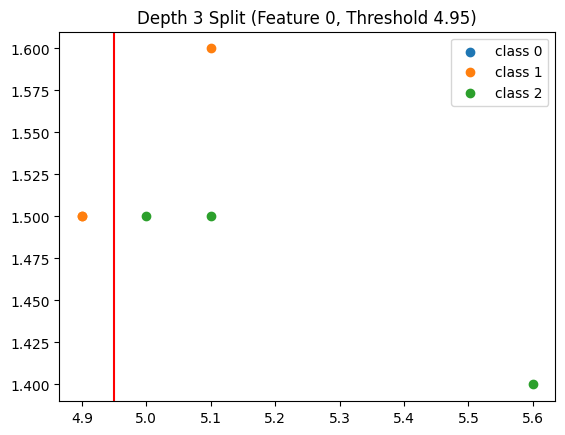


DEPTH 4 | Samples=2 | Gini=0.0000
--> LEAF NODE: Class 1

DEPTH 4 | Samples=4 | Gini=0.3750

Parent Gini: 0.3750

--- Feature 0 ---
Threshold 5.05 → Gini 0.3333, Gain 0.0417
Threshold 5.35 → Gini 0.3333, Gain 0.0417

--- Feature 1 ---
Threshold 1.45 → Gini 0.3333, Gain 0.0417
Threshold 1.55 → Gini 0.0000, Gain 0.3750

✅ BEST SPLIT FOUND: {'feature': 1, 'threshold': 1.55, 'gini': 0.0, 'gain': 0.375}

🔥 APPLYING SPLIT: Feature 1 < 1.55
Gini Decrease: 0.3750


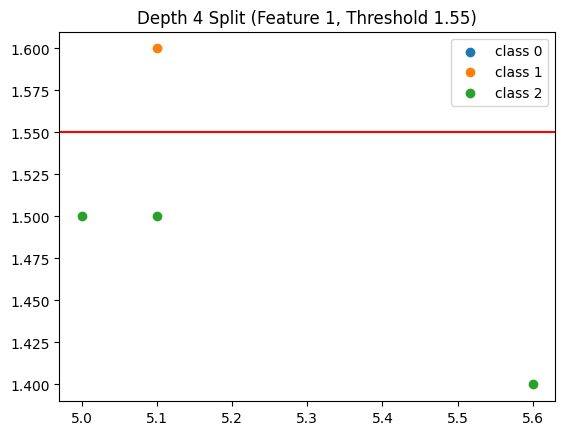


DEPTH 5 | Samples=3 | Gini=0.0000
--> LEAF NODE: Class 2

DEPTH 5 | Samples=1 | Gini=0.0000
--> LEAF NODE: Class 1

DEPTH 3 | Samples=32 | Gini=0.0000
--> LEAF NODE: Class 2


In [34]:
tree_train = build_tree_verbose(X_train, y_train, max_depth=5)

In [35]:
y_pred = predict(X_test, tree_train)

accuracy = np.mean(y_pred == y_test)

print("\n==========================")
print("TEST RESULTS")
print("==========================")
print("Accuracy:", accuracy)


TEST RESULTS
Accuracy: 0.9333333333333333


In [36]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:\n", cm)


Confusion Matrix:
 [[15  0  0]
 [ 0 14  1]
 [ 0  2 13]]


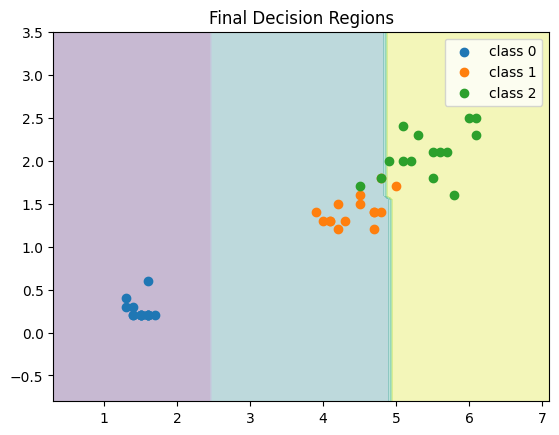

In [37]:
plot_decision_boundary(X_test, y_test, tree)

In [38]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        15
           1       0.88      0.93      0.90        15
           2       0.93      0.87      0.90        15

    accuracy                           0.93        45
   macro avg       0.93      0.93      0.93        45
weighted avg       0.93      0.93      0.93        45



In [39]:
train_acc = np.mean(predict(X_train, tree) == y_train)
test_acc = np.mean(predict(X_test, tree) == y_test)

print("Train:", train_acc)
print("Test:", test_acc)

Train: 0.9809523809523809
Test: 0.9333333333333333


In [58]:
!pip install graphviz


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [59]:
from graphviz import Digraph

def plot_tree_graph(node, feature_names):
    dot = Digraph()
    
    def add_nodes(node, parent=None, edge_label=""):
        if node.value is not None:
            label = f"Leaf\nClass {node.value}"
        else:
            label = f"{feature_names[node.feature]} < {node.threshold:.2f}"
        
        node_id = str(id(node))
        dot.node(node_id, label)
        
        if parent is not None:
            dot.edge(parent, node_id, label=edge_label)
        
        if node.value is None:
            add_nodes(node.left, node_id, "Yes")
            add_nodes(node.right, node_id, "No")
    
    add_nodes(node)
    return dot

In [60]:
feature_names = ["petal length", "petal width"]
dot = plot_tree_graph(tree, feature_names)
dot

ExecutableNotFound: failed to execute WindowsPath('dot'), make sure the Graphviz executables are on your systems' PATH

In [61]:
def print_tree(node, feature_names, indent=""):
    if node.value is not None:
        print(indent + f"Leaf → Class {node.value}")
        return
    
    feature_name = feature_names[node.feature]
    
    print(indent + f"{feature_name} < {node.threshold:.2f}?")
    
    print(indent + "├── Yes:")
    print_tree(node.left, feature_names, indent + "│   ")
    
    print(indent + "└── No:")
    print_tree(node.right, feature_names, indent + "    ")

In [62]:
feature_names = ["petal length", "petal width"]
print_tree(tree, feature_names)

petal length < 2.45?
├── Yes:
│   Leaf → Class 0
└── No:
    petal width < 1.75?
    ├── Yes:
    │   petal length < 4.95?
    │   ├── Yes:
    │   │   Leaf → Class 1
    │   └── No:
    │       Leaf → Class 2
    └── No:
        petal length < 4.85?
        ├── Yes:
        │   Leaf → Class 2
        └── No:
            Leaf → Class 2
